In [1]:
import pandas as pd

In [2]:
txt_file_path = '../data/Ads.txt'
# Sử dụng index_col='Id' để đặt cột Id làm index
df_txt = pd.read_csv(txt_file_path, sep=r'\s+', index_col='Id')
display(df_txt.head())

,youtube,facebook,newspaper,sales
Id,,,,
1,276.12,45.36,83.04,26.52
2,53.40,47.16,54.12,12.48
3,20.64,55.08,83.16,11.16
4,181.80,49.56,70.20,22.20
5,216.96,12.96,70.08,15.48


In [13]:
df_txt.info()

<class 'pandas.DataFrame'>
Index: 199 entries, 1 to 200
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   youtube      199 non-null    float64 
 1   facebook     199 non-null    float64 
 2   newspaper    199 non-null    float64 
 3   sales        199 non-null    float64 
 4   sales_level  199 non-null    category
dtypes: category(1), float64(4)
memory usage: 8.1 KB


In [3]:
# Hiển thị thống kê mô tả cho tất cả các cột số
description = df_txt.describe()
display(description)

,youtube,facebook,newspaper,sales
count,199.000000,199.000000,199.000000,199.000000
mean,176.749749,28.011256,36.805628,16.853065
std,103.198035,17.810830,26.124069,6.265850
min,0.840000,0.000000,0.360000,1.920000
25%,88.860000,12.060000,15.420000,12.480000
50%,179.760000,27.960000,31.080000,15.480000
75%,262.980000,43.860000,54.120000,20.880000
max,355.680000,59.520000,136.800000,32.400000


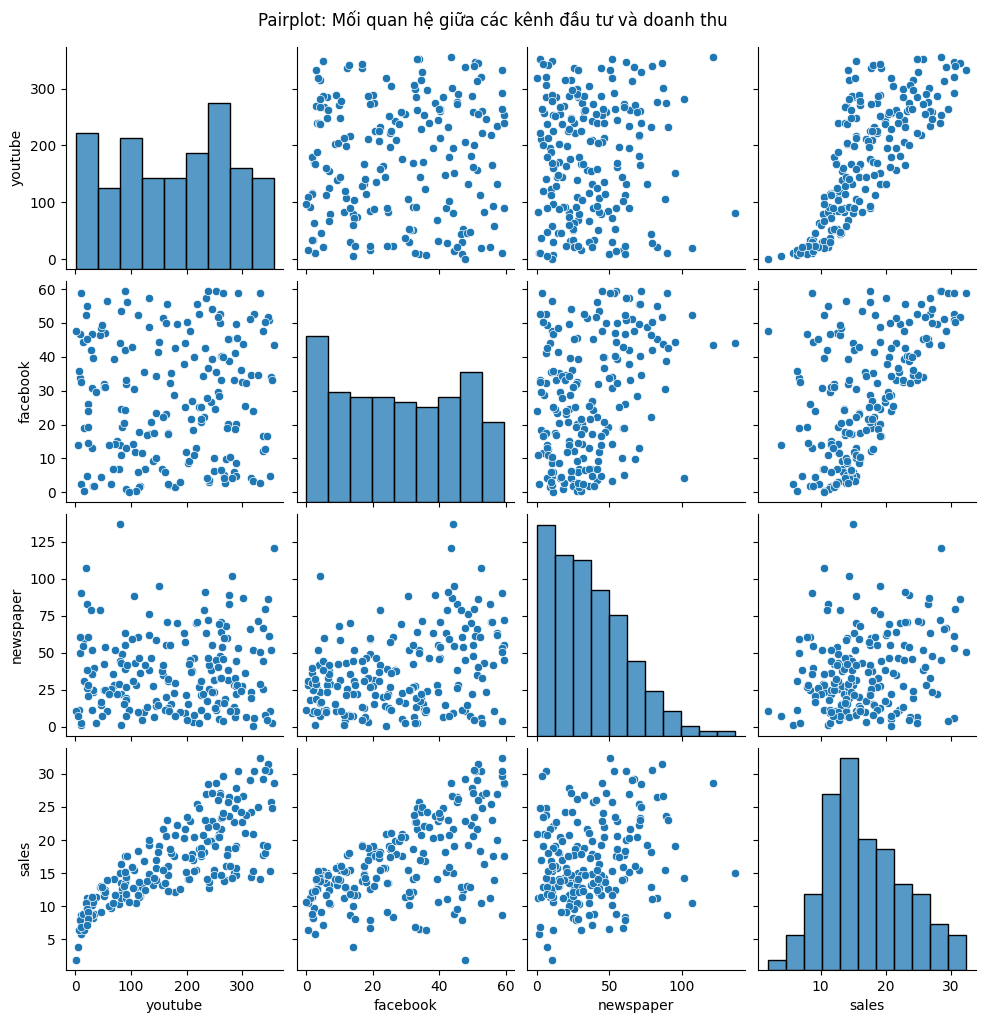

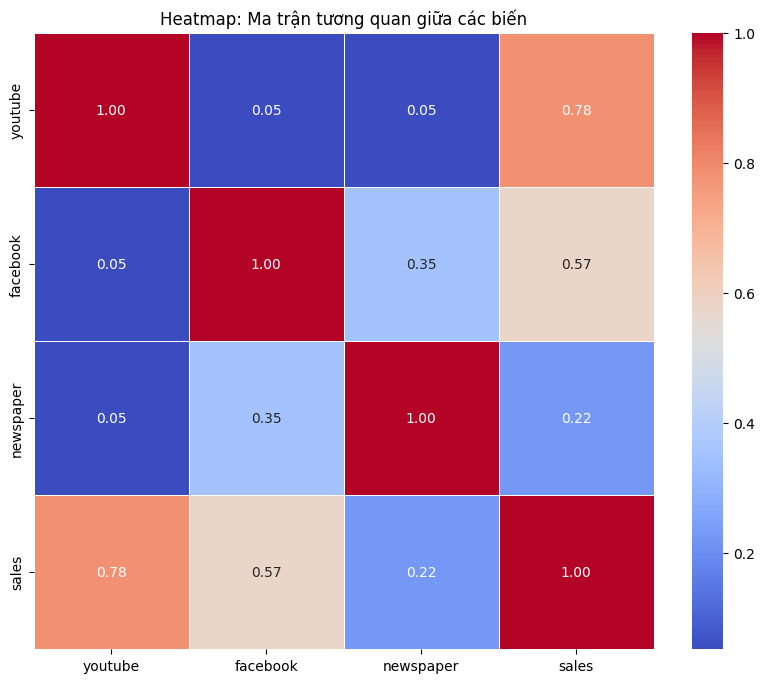

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Vẽ Pairplot
sns.pairplot(df_txt)
plt.suptitle('Pairplot: Mối quan hệ giữa các kênh đầu tư và doanh thu', y=1.02)
plt.show()

# 2. Tính ma trận tương quan
corr_matrix = df_txt.corr()

# 3. Vẽ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap: Ma trận tương quan giữa các biến')
plt.show()


In [5]:

import numpy as np

# Phân hoạch doanh thu theo các ngưỡng cụ thể: 0-10, 10-20, >20
bins = [0, 10, 20, np.inf]
labels = ['Low', 'Medium', 'High']
df_txt['sales_level'] = pd.cut(df_txt['sales'], bins=bins, labels=labels)

# Thống kê số lượng mẫu theo từng mức
print("Số lượng mẫu tin theo doanh thu ứng với 3 mức phân hoạch mới:")
display(df_txt['sales_level'].value_counts())

Số lượng mẫu tin theo doanh thu ứng với 3 mức phân hoạch mới:


sales_level
Medium    118
High       59
Low        22
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Chuẩn bị dữ liệu chung cho các mô hình
X = df_txt[['youtube', 'facebook', 'newspaper']]
y = df_txt['sales_level']

# Chia 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dữ liệu đã sẵn sàng cho KNN, SVM, Random Forest và Naive Bayes.")

Dữ liệu đã sẵn sàng cho KNN, SVM, Random Forest và Naive Bayes.


In [7]:
# Dữ liệu mới cần dự báo dùng chung
new_data = pd.DataFrame({
    'youtube': [118, 34],
    'facebook': [63, 43],
    'newspaper': [19, 14]
})
print("Dữ liệu dự báo mới đã được khởi tạo.")

Dữ liệu dự báo mới đã được khởi tạo.


### 1. Chi tiết cho mô hình K-Nearest Neighbors (KNN)

Kết quả kiểm thử KNN:
              precision    recall  f1-score   support

        High       0.88      1.00      0.93         7
         Low       1.00      1.00      1.00         4
      Medium       1.00      0.97      0.98        29

    accuracy                           0.97        40
   macro avg       0.96      0.99      0.97        40
weighted avg       0.98      0.97      0.98        40



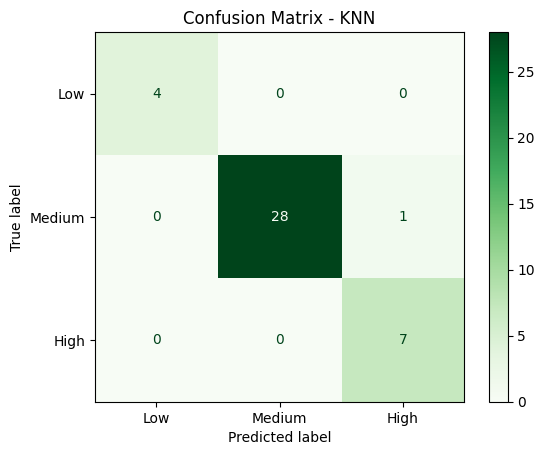

Độ chính xác trung bình KNN (k=5): 0.89
Dự báo dữ liệu mới bằng KNN: ['Medium' 'Low']


In [8]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Khởi tạo và huấn luyện
knn_model = KNeighborsClassifier(n_neighbors=4)
knn_model.fit(X_train, y_train)

# 2. Dự đoán và Kết quả kiểm thử
y_pred_knn = knn_model.predict(X_test)
print("Kết quả kiểm thử KNN:")
print(classification_report(y_test, y_pred_knn))

# 3. Ma trận hỗn loạn
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=['Low', 'Medium', 'High'])
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Low', 'Medium', 'High'])
disp_knn.plot(cmap='Greens')
plt.title('Confusion Matrix - KNN')
plt.show()

# 4. K-fold Cross Validation
knn_cv = cross_val_score(knn_model, X, y, cv=5)
print(f"Độ chính xác trung bình KNN (k=5): {knn_cv.mean():.2f}")

# 5. Dự báo dữ liệu mới
knn_new_pred = knn_model.predict(new_data)
print("Dự báo dữ liệu mới bằng KNN:", knn_new_pred)

### 2. Chi tiết cho mô hình Support Vector Machine (SVM)

Kết quả kiểm thử SVM:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         7
         Low       0.80      1.00      0.89         4
      Medium       1.00      0.97      0.98        29

    accuracy                           0.97        40
   macro avg       0.93      0.99      0.96        40
weighted avg       0.98      0.97      0.98        40



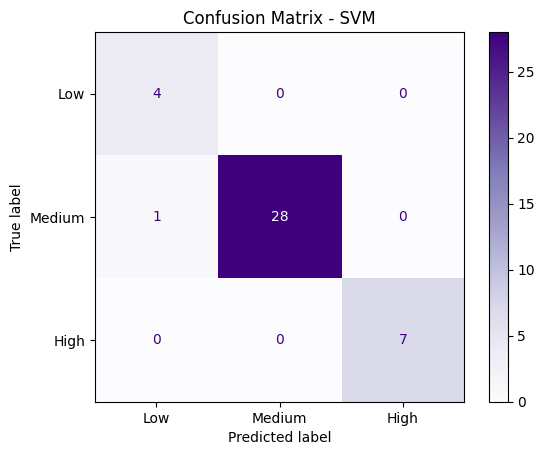

Độ chính xác trung bình SVM (k=5): 0.95
Dự báo dữ liệu mới bằng SVM: ['High' 'Medium']


In [9]:
from sklearn.svm import SVC

# 1. Khởi tạo và huấn luyện
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# 2. Dự đoán và Kết quả kiểm thử
y_pred_svm = svm_model.predict(X_test)
print("Kết quả kiểm thử SVM:")
print(classification_report(y_test, y_pred_svm))

# 3. Ma trận hỗn loạn
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=['Low', 'Medium', 'High'])
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Low', 'Medium', 'High'])
disp_svm.plot(cmap='Purples')
plt.title('Confusion Matrix - SVM')
plt.show()

# 4. K-fold Cross Validation
svm_cv = cross_val_score(svm_model, X, y, cv=5)
print(f"Độ chính xác trung bình SVM (k=5): {svm_cv.mean():.2f}")

# 5. Dự báo dữ liệu mới
svm_new_pred = svm_model.predict(new_data)
print("Dự báo dữ liệu mới bằng SVM:", svm_new_pred)

### 3. Chi tiết cho mô hình Random Forest

Kết quả kiểm thử Random Forest:
              precision    recall  f1-score   support

        High       0.78      1.00      0.88         7
         Low       1.00      1.00      1.00         4
      Medium       1.00      0.93      0.96        29

    accuracy                           0.95        40
   macro avg       0.93      0.98      0.95        40
weighted avg       0.96      0.95      0.95        40



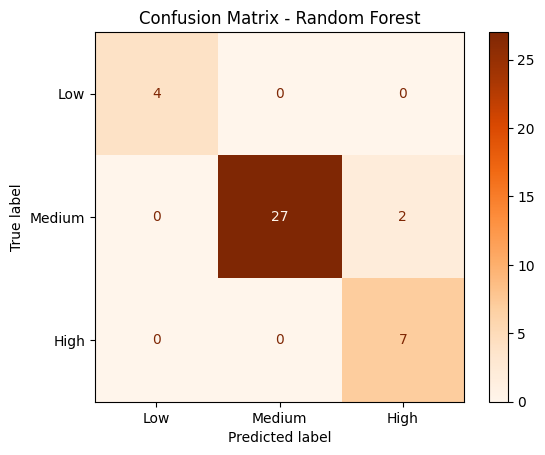

Độ chính xác trung bình Random Forest (k=5): 0.91


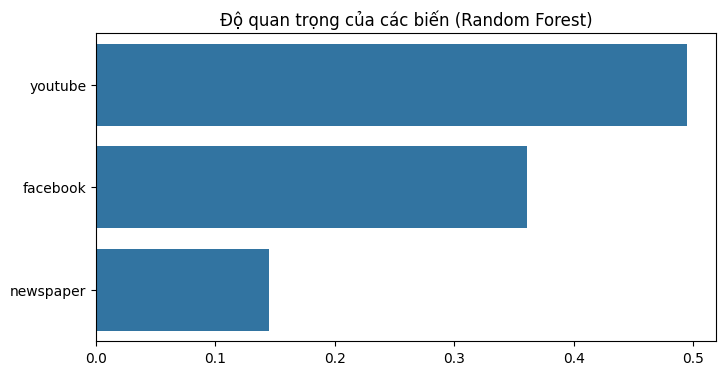

Dự báo dữ liệu mới bằng Random Forest: ['Medium' 'Medium']


In [12]:
from sklearn.ensemble import RandomForestClassifier

# 1. Khởi tạo và huấn luyện
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Dự đoán và Kết quả kiểm thử
y_pred_rf = rf_model.predict(X_test)
print("Kết quả kiểm thử Random Forest:")
print(classification_report(y_test, y_pred_rf))

# 3. Ma trận hỗn loạn
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['Low', 'Medium', 'High'])
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Low', 'Medium', 'High'])
disp_rf.plot(cmap='Oranges')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# 4. K-fold Cross Validation
rf_cv = cross_val_score(rf_model, X, y, cv=5)
print(f"Độ chính xác trung bình Random Forest (k=5): {rf_cv.mean():.2f}")

# 5. Trực quan hóa (Feature Importance - vì Random Forest không vẽ cây đơn giản như Decision Tree)
importances = rf_model.feature_importances_
plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=['youtube', 'facebook', 'newspaper'])
plt.title('Độ quan trọng của các biến (Random Forest)')
plt.show()

# 6. Dự báo dữ liệu mới
rf_new_pred = rf_model.predict(new_data)
print("Dự báo dữ liệu mới bằng Random Forest:", rf_new_pred)

### 4. Chi tiết cho mô hình Naive Bayes

Kết quả kiểm thử Naive Bayes:
              precision    recall  f1-score   support

        High       0.88      1.00      0.93         7
         Low       0.57      1.00      0.73         4
      Medium       1.00      0.86      0.93        29

    accuracy                           0.90        40
   macro avg       0.82      0.95      0.86        40
weighted avg       0.94      0.90      0.91        40



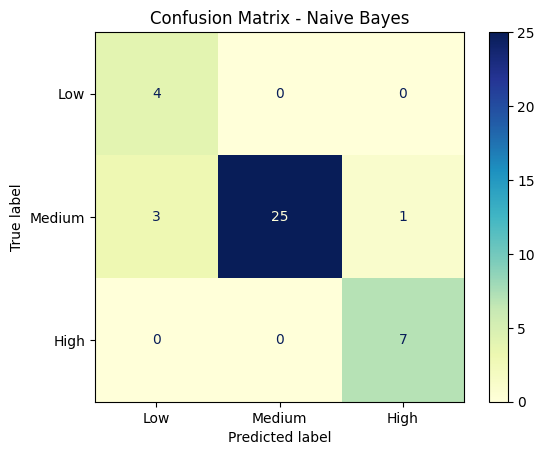

Độ chính xác trung bình Naive Bayes (k=5): 0.91
Dự báo dữ liệu mới bằng Naive Bayes: ['Medium' 'Low']


In [11]:
from sklearn.naive_bayes import GaussianNB

# 1. Khởi tạo và huấn luyện
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 2. Dự đoán và Kết quả kiểm thử
y_pred_nb = nb_model.predict(X_test)
print("Kết quả kiểm thử Naive Bayes:")
print(classification_report(y_test, y_pred_nb))

# 3. Ma trận hỗn loạn
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=['Low', 'Medium', 'High'])
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Low', 'Medium', 'High'])
disp_nb.plot(cmap='YlGnBu')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

# 4. K-fold Cross Validation
nb_cv = cross_val_score(nb_model, X, y, cv=5)
print(f"Độ chính xác trung bình Naive Bayes (k=5): {nb_cv.mean():.2f}")

# 5. Dự báo dữ liệu mới
nb_new_pred = nb_model.predict(new_data)
print("Dự báo dữ liệu mới bằng Naive Bayes:", nb_new_pred)